# Makemore (part 1)

##### This notebook is based on [this video](https://www.youtube.com/watch?v=PaCmpygFfXo)

### Imports

In [30]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

### Get and explore data

We have file with American names, let's download it

In [5]:
data_url = "https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt"
data_filename = "names.txt"

!wget -q -nc -O {data_filename} {data_url}

In [6]:
words = open('names.txt', 'r').read().splitlines()

In [7]:
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [8]:
len(words)

32033

In [9]:
min(len(w) for w in words), max(len(w) for w in words), sum(len(w) for w in words)/len(words)

(2, 15, 6.122217712983486)

### Statistical Approach

We want to add `<S>tart` and `<E>nd` token to name, so we will know where the name starts or ends. Let's create bigrams for every name in the file. For example, we have name `emma`, with added tokens it equals to `<S>emma<E>` bigrams for this name are:
`<S>e, em, mm, ma, a<E>`

In [10]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

sb = sorted(b.items(), key=lambda kv: -kv[1])
sb[:10], sb[-10:]

([(('n', '<E>'), 6763),
  (('a', '<E>'), 6640),
  (('a', 'n'), 5438),
  (('<S>', 'a'), 4410),
  (('e', '<E>'), 3983),
  (('a', 'r'), 3264),
  (('e', 'l'), 3248),
  (('r', 'i'), 3033),
  (('n', 'a'), 2977),
  (('<S>', 'k'), 2963)],
 [(('g', 'v'), 1),
  (('d', 'q'), 1),
  (('x', 'b'), 1),
  (('w', 'z'), 1),
  (('h', 'q'), 1),
  (('j', 'b'), 1),
  (('x', 'm'), 1),
  (('w', 'g'), 1),
  (('t', 'b'), 1),
  (('z', 'x'), 1)])

We can change `<S>` and `<E>` tokens to only one token. And for simplicity we will use a character. Since we are usign all alphabet for names. Let's choose character `.` as both start and end token. It's safe to use `.`, because it never appears in names

In [11]:
b = {}
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

sb = sorted(b.items(), key=lambda kv: -kv[1])
sb[:10], sb[-10:]

([(('n', '.'), 6763),
  (('a', '.'), 6640),
  (('a', 'n'), 5438),
  (('.', 'a'), 4410),
  (('e', '.'), 3983),
  (('a', 'r'), 3264),
  (('e', 'l'), 3248),
  (('r', 'i'), 3033),
  (('n', 'a'), 2977),
  (('.', 'k'), 2963)],
 [(('g', 'v'), 1),
  (('d', 'q'), 1),
  (('x', 'b'), 1),
  (('w', 'z'), 1),
  (('h', 'q'), 1),
  (('j', 'b'), 1),
  (('x', 'm'), 1),
  (('w', 'g'), 1),
  (('t', 'b'), 1),
  (('z', 'x'), 1)])

Instead of using dictionary, let's put this data to tensor. So it will be easier to manipulate data. We have 26 letters in English alphabet + 1 `.` character, total is 27.

In [12]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

For bigram we have 27 possible options as the first character and 27 options as the second character. Therefore we need to create tensor with two dims 27x27.

In [13]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [14]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    idxs = [stoi[ch] for ch in chs]
    for idx1, idx2 in zip(idxs, idxs[1:]):
        N[idx1, idx2] += 1

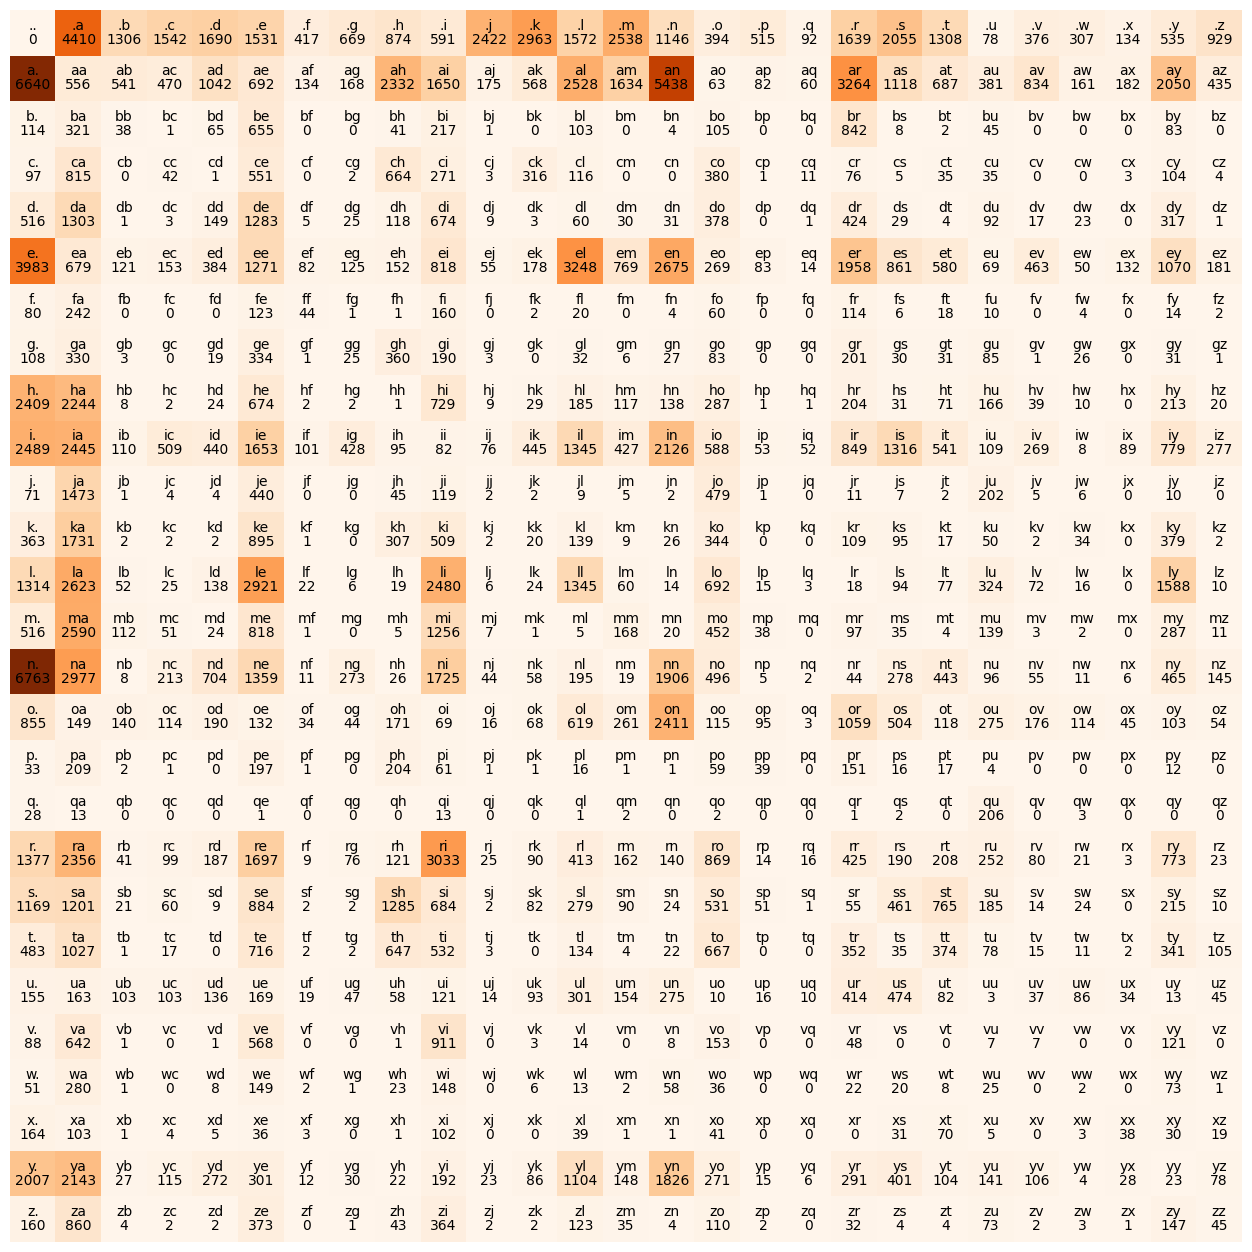

In [15]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Oranges')
plt.axis('off')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='black')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='black')

In [16]:
ch1, ch2 = 'ab'
idx1, idx2 = stoi[ch1], stoi[ch2]
N[idx1, idx2].item()

541

Now `N[idx1, idx2]` contains the count of occurrences of the corresponding digram. But we want to have probability there

In [17]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [18]:
P = (N+1).float()  # we want that all numbers will be more than zero
P = P / P.sum(1, keepdims=True)

In [19]:
P.sum(0)  # by columns, shouldn't be 1s

tensor([3.0023, 5.3111, 0.1847, 0.2300, 0.3840, 3.2304, 0.1100, 0.1341, 1.1715,
        2.7497, 0.1235, 0.3330, 1.1707, 0.4055, 1.2774, 1.3664, 0.1091, 0.0295,
        1.6097, 0.7284, 0.5734, 1.1475, 0.1643, 0.1291, 0.1069, 1.0258, 0.1921])

In [20]:
P.sum(1)  # by rows, should be 1s

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [21]:
ch1, ch2 = 'ab'
idx1, idx2 = stoi[ch1], stoi[ch2]
P[idx1, idx2].item()

0.01598254218697548

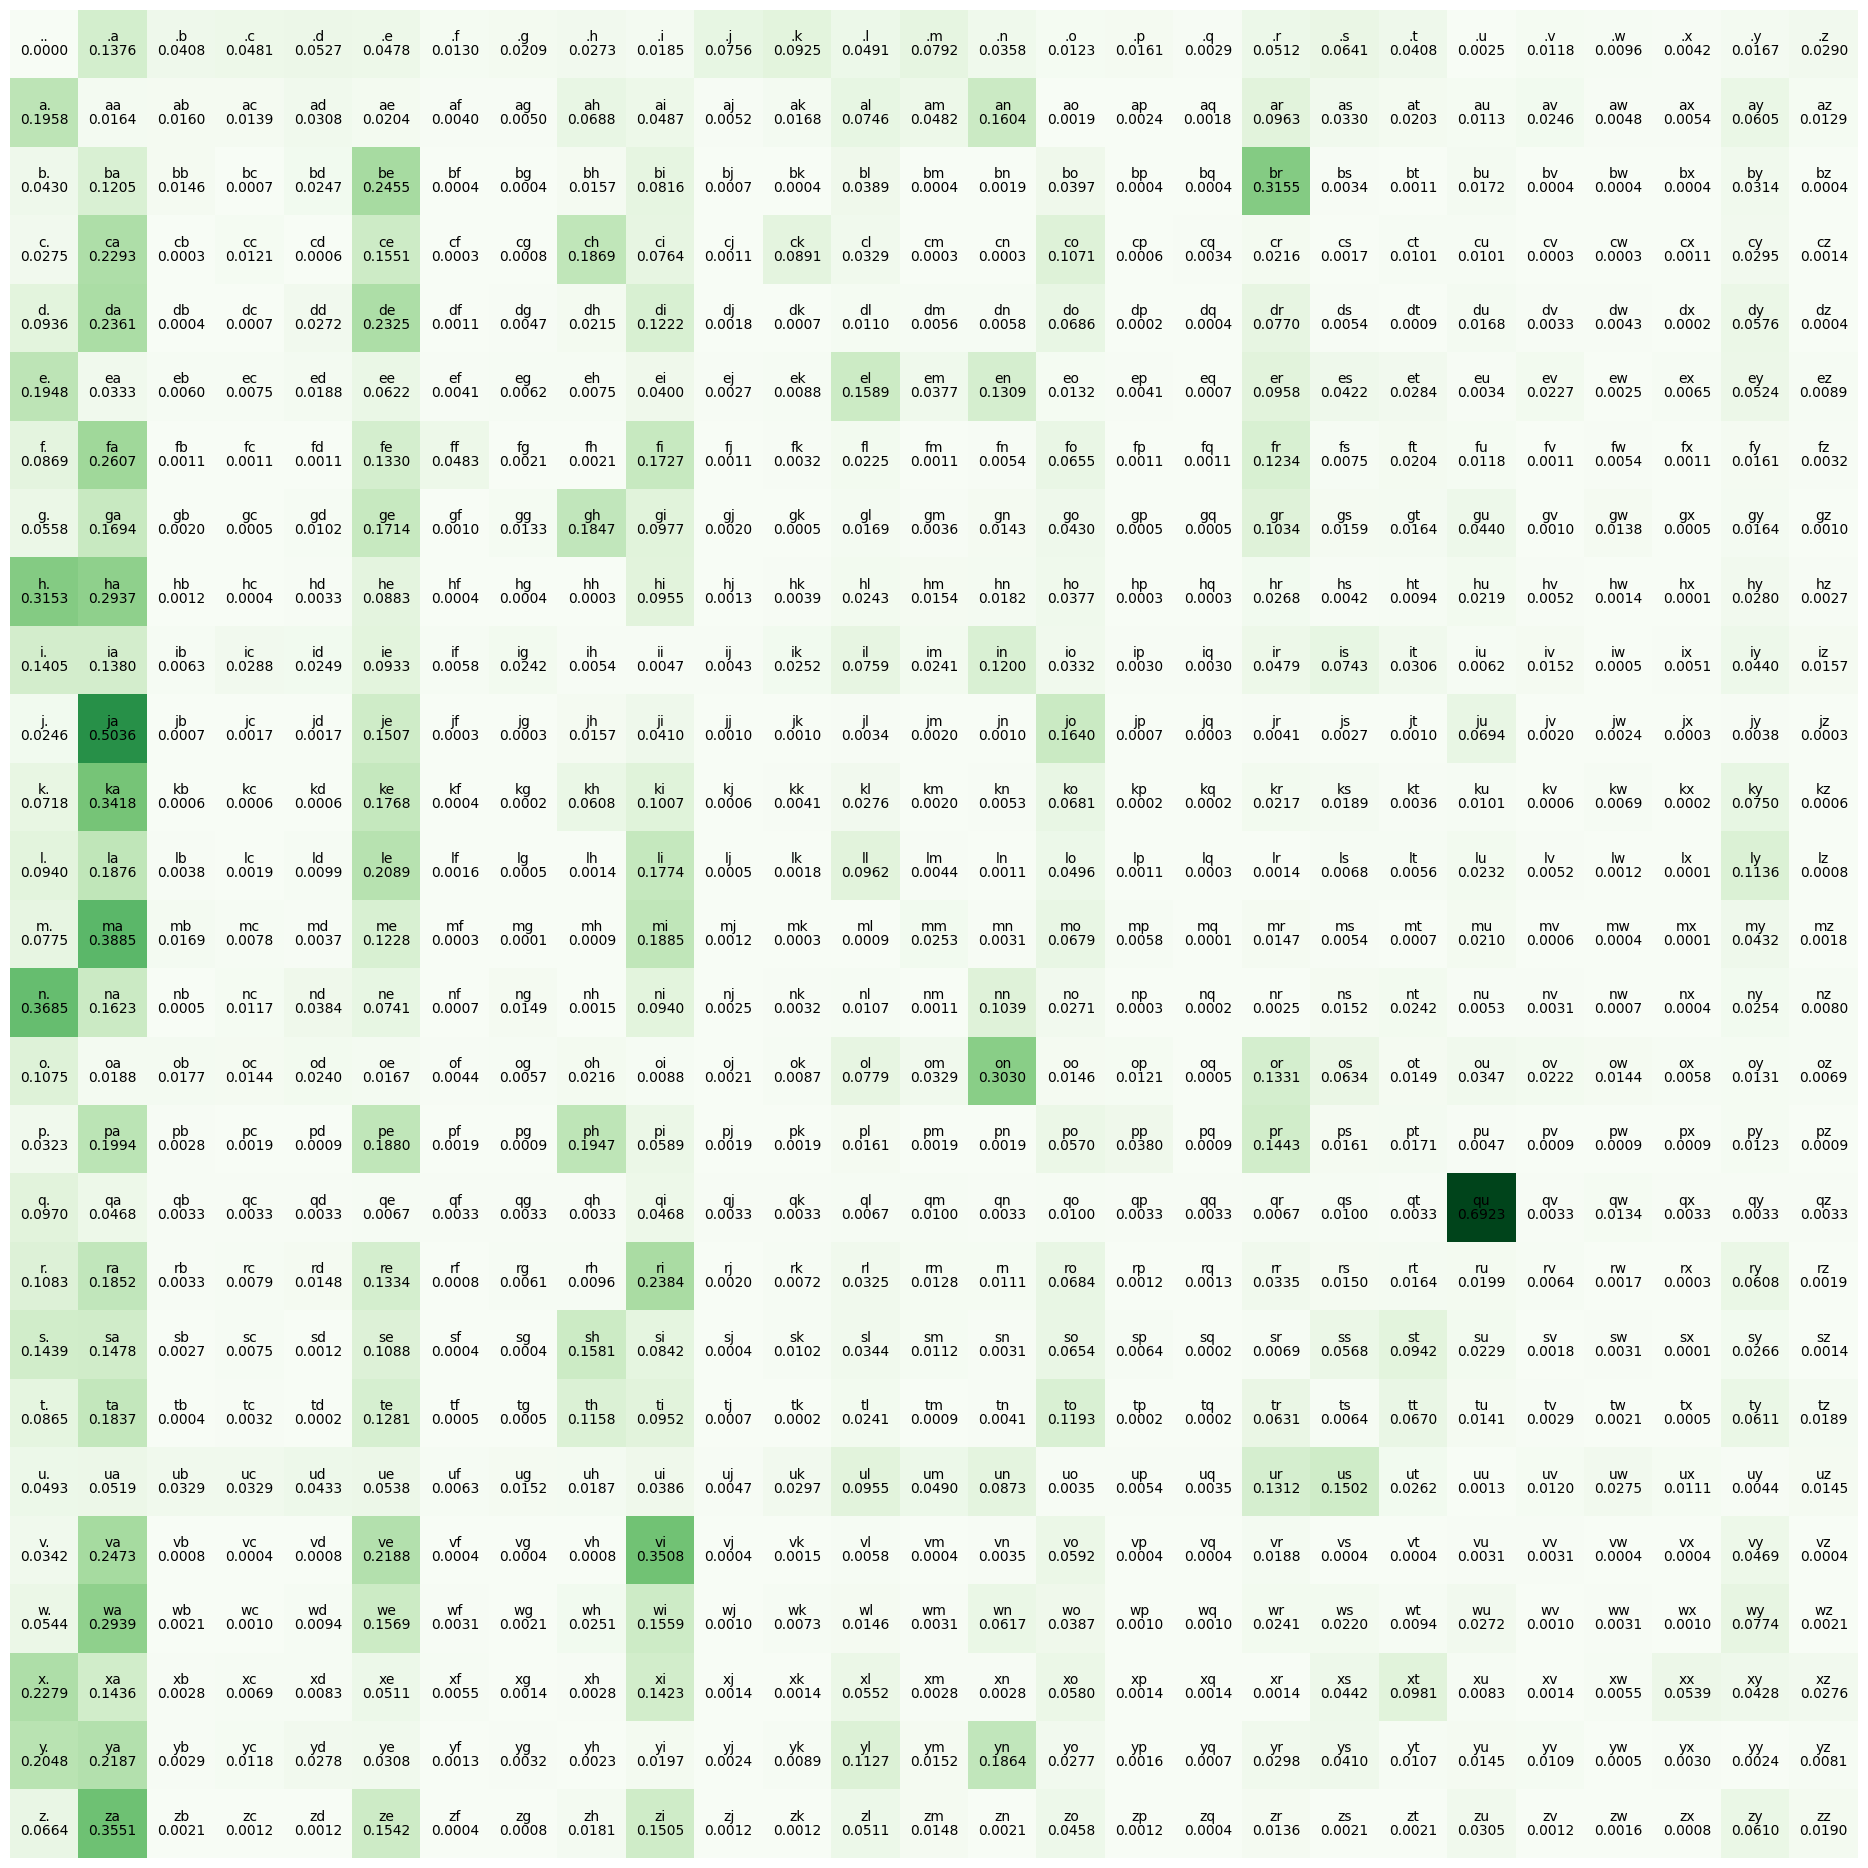

In [22]:
plt.figure(figsize=(24, 24))
plt.imshow(P, cmap='Greens')
plt.axis('off')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='black')
        plt.text(j, i, f'{P[i, j].item():.4f}', ha='center', va='top', color='black')

In [23]:
g = torch.Generator().manual_seed(2147483647)
idx = torch.multinomial(P[0], num_samples=1, replacement=True, generator=g).item()
itos[idx]

'c'

In [24]:
torch.multinomial(P[0], num_samples=100, replacement=True, generator=g)

tensor([ 9, 18,  2,  5,  3,  1, 13, 11, 11, 22, 11, 15, 26,  2, 18, 13, 10,  1,
        15,  2,  3, 15, 10, 12,  4,  9,  3,  4,  6,  4, 19, 10,  3,  8,  4, 10,
        13, 14, 13, 10, 19, 11,  8, 13,  5,  5,  6, 25, 20, 10, 18,  1,  8,  3,
         2, 20,  1,  1,  3, 10, 11, 25, 18,  1,  9, 11,  8, 12,  3, 12, 19,  9,
        18, 13,  4,  4, 13, 13,  8, 13,  1,  2,  4,  1,  6,  1,  1, 10, 14, 10,
        13, 12, 10,  1,  1, 20, 18, 20, 19,  1])

In [25]:
def statistic_generate(n_samples=5):
    result = []
    g = torch.Generator().manual_seed(2147483647)
    for i in range(n_samples):
        out = []
        idx = 0
        while True:
            p = P[idx]
            idx = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
            if idx == 0:
                break
            out.append(itos[idx])
        result.append(''.join(out))
    return result

In [26]:
statistic_generate(30)

['cexze',
 'momasurailezitynn',
 'konimittain',
 'llayn',
 'ka',
 'da',
 'staiyaubrtthrigotai',
 'moliellavo',
 'ke',
 'teda',
 'ka',
 'emimmsade',
 'enkaviyny',
 'ftlspihinivenvorhlasu',
 'dsor',
 'br',
 'jol',
 'pen',
 'aisan',
 'ja',
 'feniee',
 'zem',
 'deru',
 'firit',
 'gaikajahahbevare',
 'kiysthelenaririenah',
 'keen',
 'x',
 'al',
 'kal']

Note from Andrej Karpathy:
```
# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)
```

In [92]:
# Calculate average negative log likelihood
# We use it to evaluate model quality, for loss in the next approach
log_likelihood = 0.0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    idxs = [stoi[ch] for ch in chs]
    for idx1, idx2 in zip(idxs, idxs[1:]):
        prob = P[idx1, idx2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

nll = -log_likelihood
avg_nll = nll/n
print(f'{log_likelihood=}')
print(f'{nll=}')
print(f'{avg_nll=}')    

log_likelihood=tensor(-559951.5625)
nll=tensor(559951.5625)
avg_nll=tensor(2.4544)


### Neural Network Approach

In [28]:
# Create the training set of bigrams (x, y)
def create_training_set(words):
    xs, ys = [], []
    for w in words:
        chs = ['.'] + list(w) + ['.']
        idxs = [stoi[ch] for ch in chs]
        for idx1, idx2 in zip(idxs, idxs[1:]):
            xs.append(idx1)
            ys.append(idx2)
    return torch.tensor(xs), torch.tensor(ys)

In [31]:
xs, ys = create_training_set(words[:1])
xs, ys

(tensor([ 0,  5, 13, 13,  1]), tensor([ 5, 13, 13,  1,  0]))

We can't just send index to nn. We need to make [one-hot encoding](https://en.wikipedia.org/wiki/One-hot)

In [33]:
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [36]:
xenc.shape, xenc.dtype

(torch.Size([5, 27]), torch.float32)

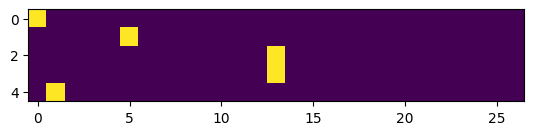

In [35]:
plt.imshow(xenc)

Since we have 27 dims vector for one character, let's create weight matrix for one perceptron with 27 inputs

In [39]:
W = torch.randn((27, 1))
W.T

tensor([[-0.4944, -0.8369,  0.1143,  1.1455,  0.4799,  1.3771, -0.7630,  1.0164,
         -0.1785, -0.5360,  0.5632,  2.2441,  1.7397,  1.0447,  0.0506, -2.0080,
         -0.8731,  0.5751, -1.5120,  0.0672,  0.8957,  1.5128,  0.5418,  0.1549,
         -2.1488,  1.8636, -0.7089]])

In [43]:
logits = xenc @ W  # log-counts
# tensor(5, 27) @ tensor(27, 1) => tensor(5, 1)
logits

tensor([[-0.4944],
        [ 1.3771],
        [ 1.0447],
        [ 1.0447],
        [-0.8369]])

Let's create 27 perceptrons, each with 27 inputs, so we have 27 outputs

In [49]:
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)
xenc = F.one_hot(xs, num_classes=27).float()
logits = xenc @ W
counts = logits.exp()  # equivalent N
counts

tensor([[ 4.7940,  0.7888,  0.9730,  0.3326,  1.3309,  0.9708,  0.2129,  1.8311,
          1.0824,  2.4710,  0.6242,  2.1964,  0.7200,  0.6486,  3.9469, 18.7908,
          4.7673,  0.1967,  1.9683,  0.4315,  2.6775,  0.8621,  0.2277,  1.5656,
          0.9317, 12.1434, 11.5281],
        [ 1.6038,  4.4060,  1.3737,  2.8830, 11.0032,  1.5972,  0.5187,  1.8527,
          0.5369,  1.6654,  3.8818,  1.2642,  0.6339,  0.9987,  0.5995,  1.7432,
          1.6073,  0.2499,  5.0680,  1.1876,  2.6871,  1.6596,  2.7728,  0.1486,
          0.6521,  0.1193,  2.6128],
        [ 1.2136,  2.8669,  1.8850,  1.2942,  2.6224,  0.7799,  1.0251,  0.9701,
          4.7691,  0.6386,  0.2910,  3.0710,  0.5098,  1.0386,  0.5719,  0.4373,
          2.2763,  0.4719,  2.5289,  0.2265,  0.8082,  0.3054,  0.5164,  0.7918,
          4.6866,  1.8232,  0.4921],
        [ 1.2136,  2.8669,  1.8850,  1.2942,  2.6224,  0.7799,  1.0251,  0.9701,
          4.7691,  0.6386,  0.2910,  3.0710,  0.5098,  1.0386,  0.5719,  0.4373

In [50]:
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
         0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
         0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
        [0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
         0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
         0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0150, 0.0086,

In [51]:
probs.shape

torch.Size([5, 27])

In [52]:
nlls = torch.zeros(5)
for i in range(5):
    x = xs[i].item()  # input character index
    y = ys[i].item()  # label character index
    print('-'*10)
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x}, {y})')
    print(f'{probs[i]=}')
    p = probs[i, y]
    print(f'probability assigned by the net to the correct character: {p.item()}')
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('='*10)
print('avg neg log likelihood, i.e. loss = ', nlls.mean().item())

----------
bigram example 1: .e (indexes 0, 5)
probs[i]=tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
probability assigned by the net to the correct character: 0.01228625513613224
log likelihood: -4.399273872375488
negative log likelihood: 4.399273872375488
----------
bigram example 2: em (indexes 5, 13)
probs[i]=tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
probability assigned by the net to the correct character: 0.018050700426101685
log likelihood: -4.014570713043213
negative log likelihood: 4.014570713043213
----------
bigram example 3: mm (indexes 13, 13)
probs[i]=tensor([0.0312, 0.0737, 0.0484, 0.

### Optimization

In [93]:
# create bigram dataset (xs, ys) for all names
xs, ys = create_training_set(words)

In [58]:
num = xs.nelement()
print('number of examples: ', num)

number of examples:  228146


In [68]:
g = torch.Generator().manual_seed(2147483647)
# need to set requires_grad=True, so we can perform backprop
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [69]:
# gradient descent
for k in range(300):
    # forward pass
    xenc = F.one_hot(xs, num_classes=27).float()  # input to the network: one-hot encoding
    logits = xenc @ W  # predict log-counts
    counts = logits.exp()  # counts, equivalent N
    probs = counts / counts.sum(1, keepdims=True)  # probs for next character
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()  # the bigger 0.01*(W**2).mean(), the smother probs distribution
    if k == 0 or (k+1)%50==0:
        print(loss.item())

    # backward pass
    W.grad = None  # set to zero the gradient
    loss.backward()

    # update
    W.data += -50 * W.grad

3.7686190605163574
2.5107581615448
2.4901304244995117
2.484975576400757
2.4829957485198975
2.482038736343384
2.4815075397491455


In [78]:
# sample from the model
g = torch.Generator().manual_seed(2147483647)
for i in range(30):
    out = []
    idx = 0
    while True:
        # -----
        # Before
        # p = P[idx]
        # -----
        # Now
        xenc = F.one_hot(torch.tensor([idx]), num_classes=27).float()
        logits = xenc @ W  # predict log-counts
        counts = logits.exp()  # counts, equivalent N
        p = counts / counts.sum(1, keepdims=True)  # probs for next character
        # -----
        idx = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if idx == 0:
            break
        out.append(itos[idx])
    print(''.join(out))

cexze
momasurailezityha
konimittain
llayn
ka
da
staiyaubrtthrigotai
moliellavo
ke
teda
ka
emimmsade
enkaviyny
fobspehinivenvtahlasu
dsor
br
jol
pen
aisan
ja
feniee
zem
deru
firit
gaikajahahbevare
kiysthelenaririenah
keen
x
al
kalmahavazeeromysos


In [77]:
statistic_generate(30)

['cexze',
 'momasurailezitynn',
 'konimittain',
 'llayn',
 'ka',
 'da',
 'staiyaubrtthrigotai',
 'moliellavo',
 'ke',
 'teda',
 'ka',
 'emimmsade',
 'enkaviyny',
 'ftlspihinivenvorhlasu',
 'dsor',
 'br',
 'jol',
 'pen',
 'aisan',
 'ja',
 'feniee',
 'zem',
 'deru',
 'firit',
 'gaikajahahbevare',
 'kiysthelenaririenah',
 'keen',
 'x',
 'al',
 'kal']

While we have almost the same names for both approaches, we should have almost the same probabilities. Let's create one-hot encoding for all 27 characters, put them in our model, calculate probabilities and compare them with probs from the statistical approach

In [79]:
xenc = F.one_hot(torch.tensor(list(range(27))), num_classes=27).float()
logits = xenc @ W  # predict log-counts
counts = logits.exp()  # counts, equivalent N
p = counts / counts.sum(1, keepdims=True)  # probs for next character

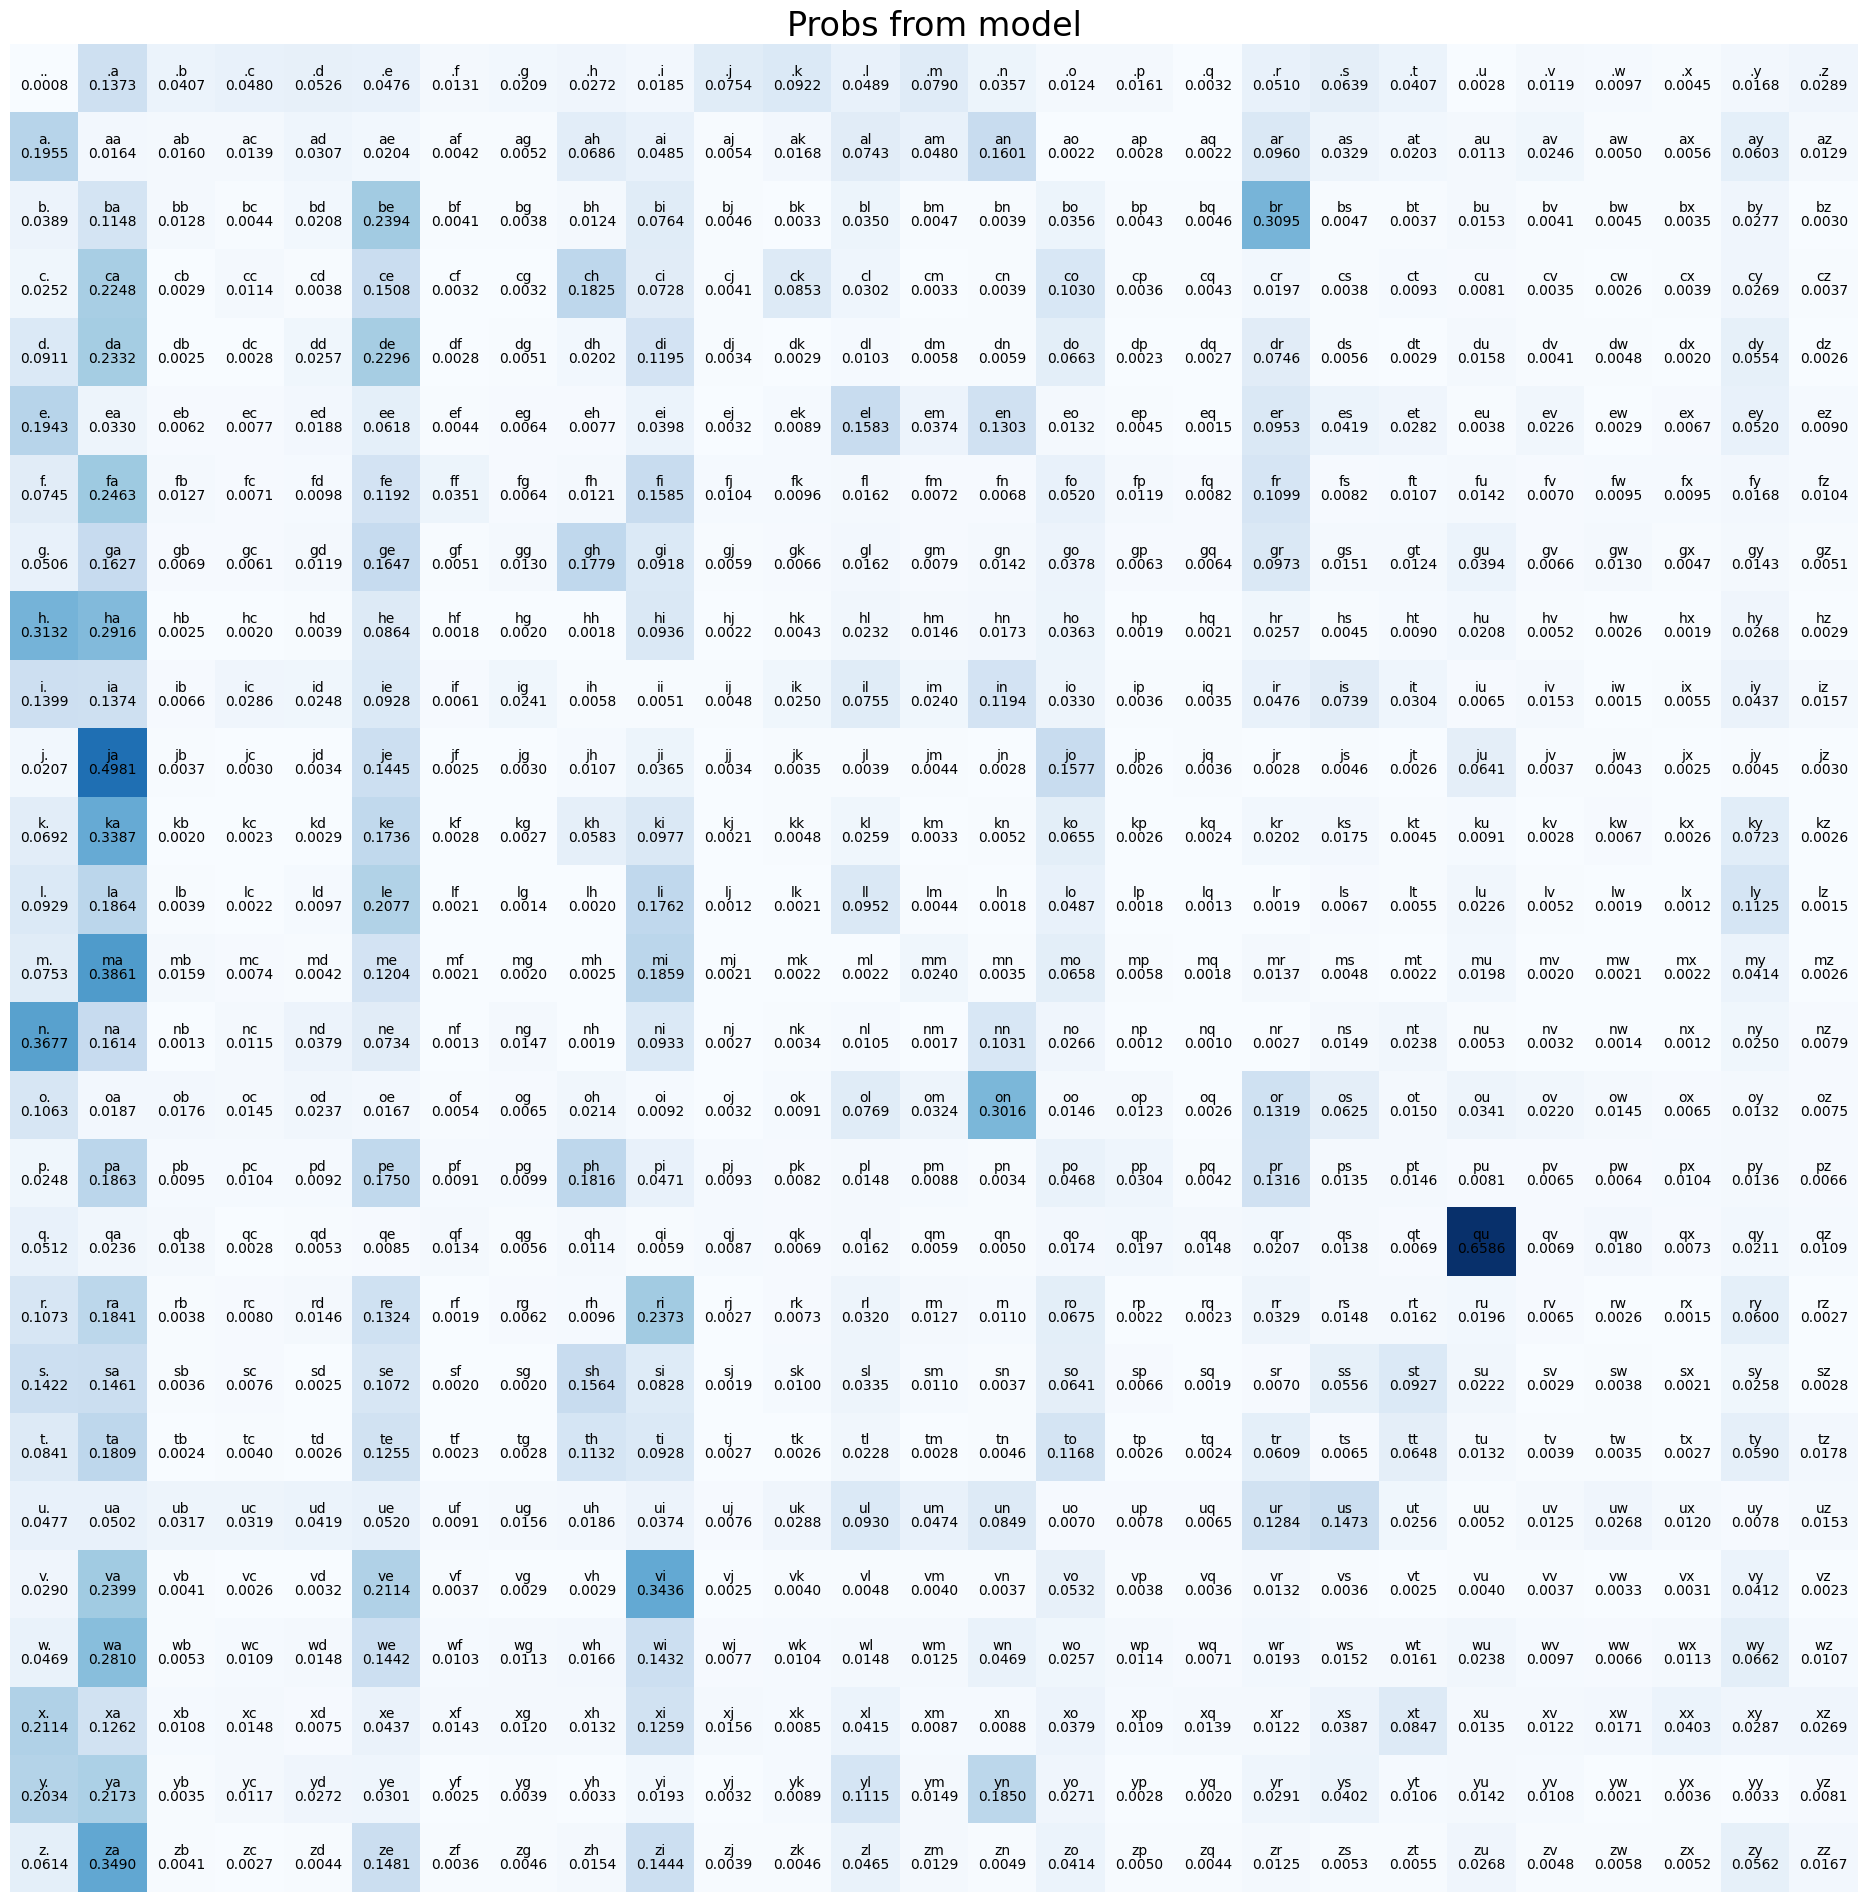

In [90]:
plt.figure(figsize=(24, 24))
plt.imshow(p.data, cmap='Blues')
plt.axis('off')
plt.title('Probs from model approach', fontdict={'fontsize':24})
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='black')
        plt.text(j, i, f'{p[i, j].item():.4f}', ha='center', va='top', color='black')

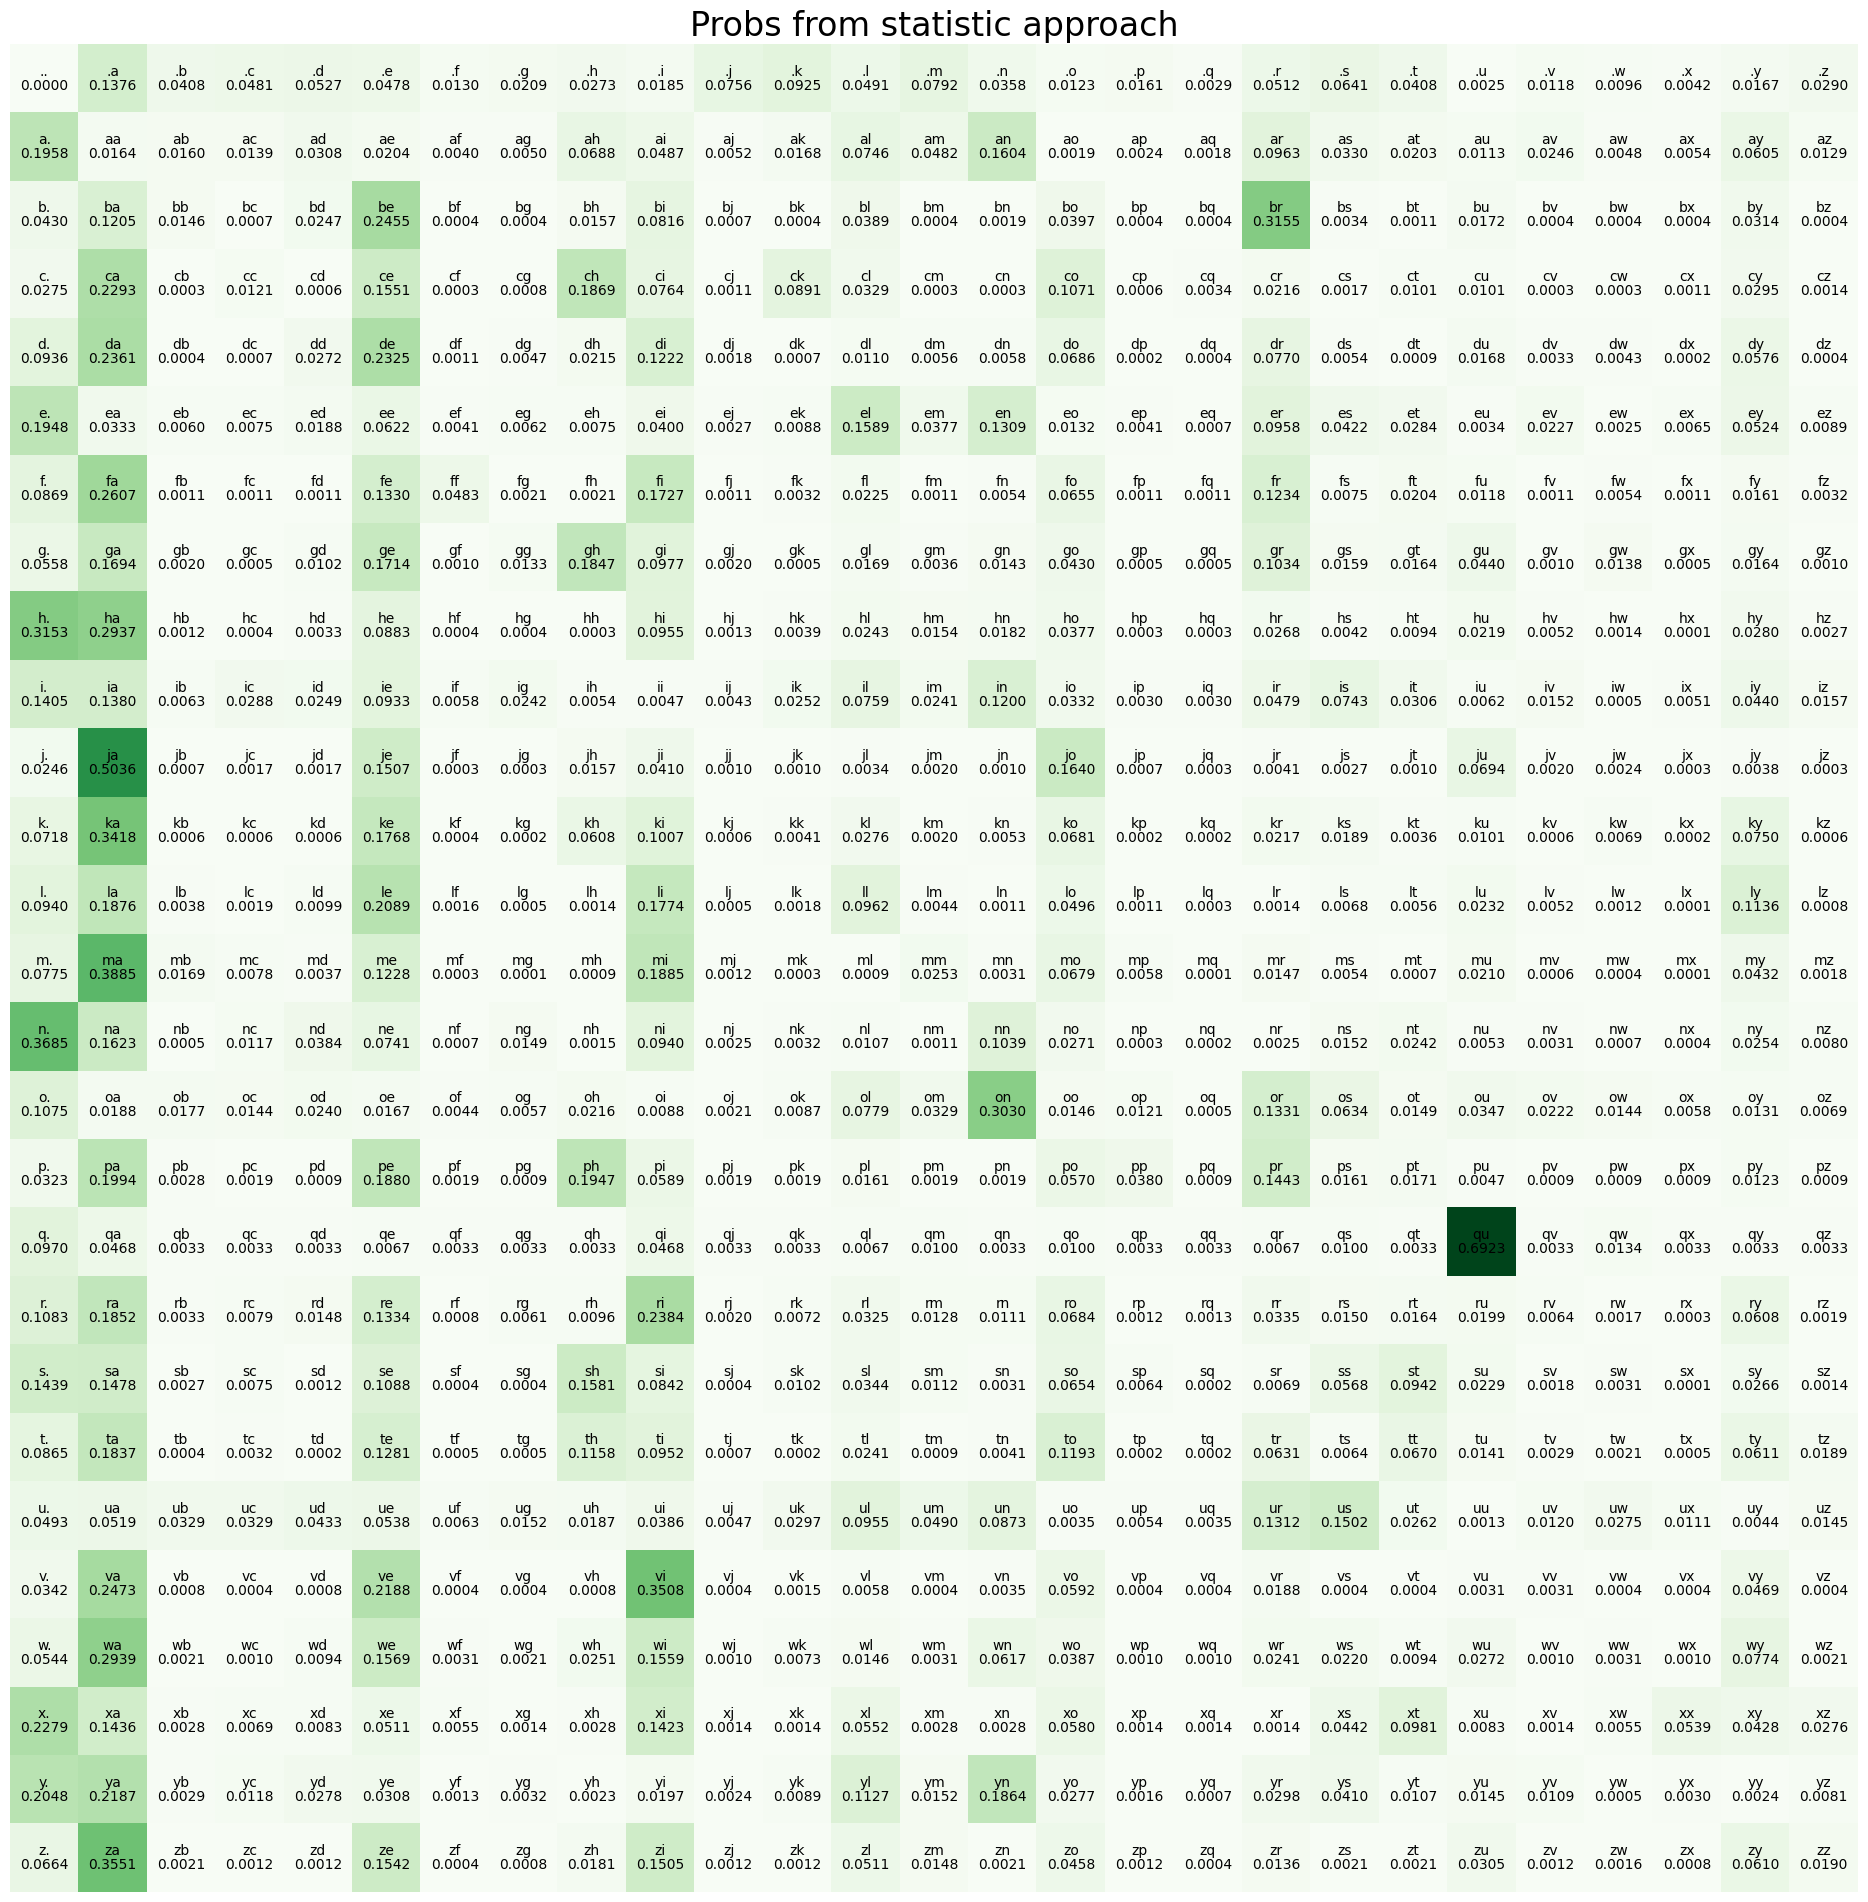

In [91]:
plt.figure(figsize=(24, 24))
plt.imshow(P, cmap='Greens')
plt.axis('off')
plt.title('Probs from statistic approach', fontdict={'fontsize':24})
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='black')
        plt.text(j, i, f'{P[i, j].item():.4f}', ha='center', va='top', color='black')

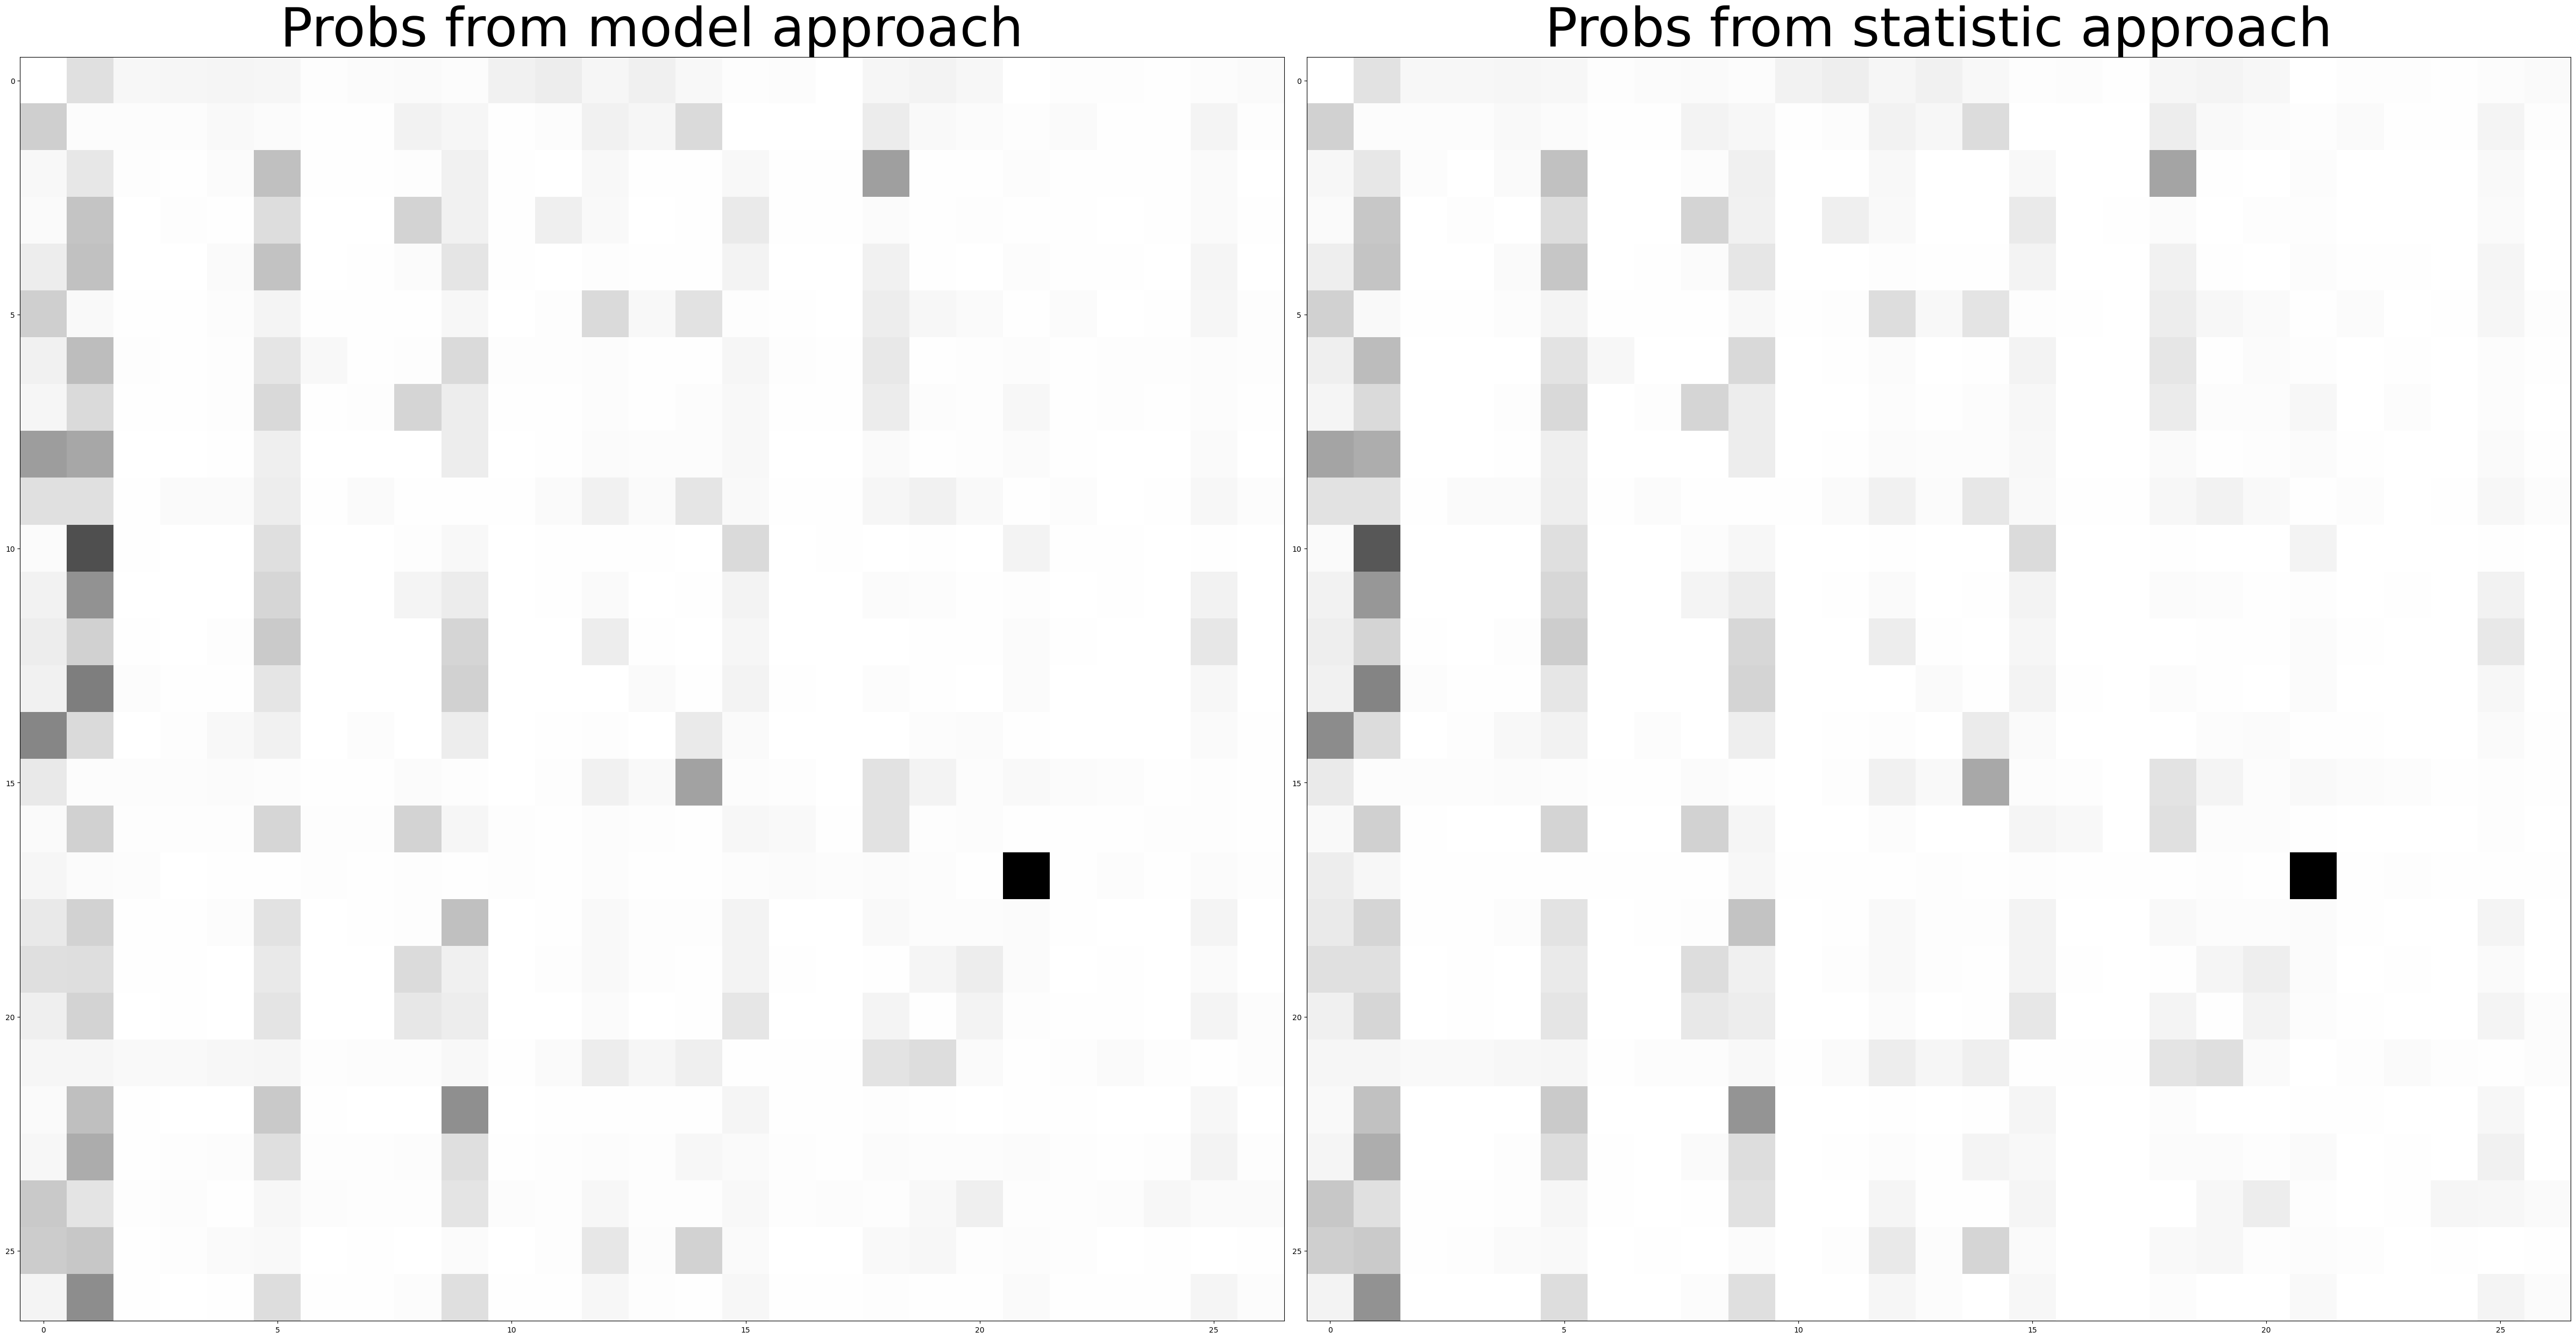

In [101]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(48, 24))
ax1.imshow(p.data, cmap='Grays')
ax1.set_title('Probs from model approach', fontdict={'fontsize':72})
ax2.imshow(P, cmap='Grays')
ax2.set_title('Probs from statistic approach', fontdict={'fontsize':72})
plt.tight_layout()

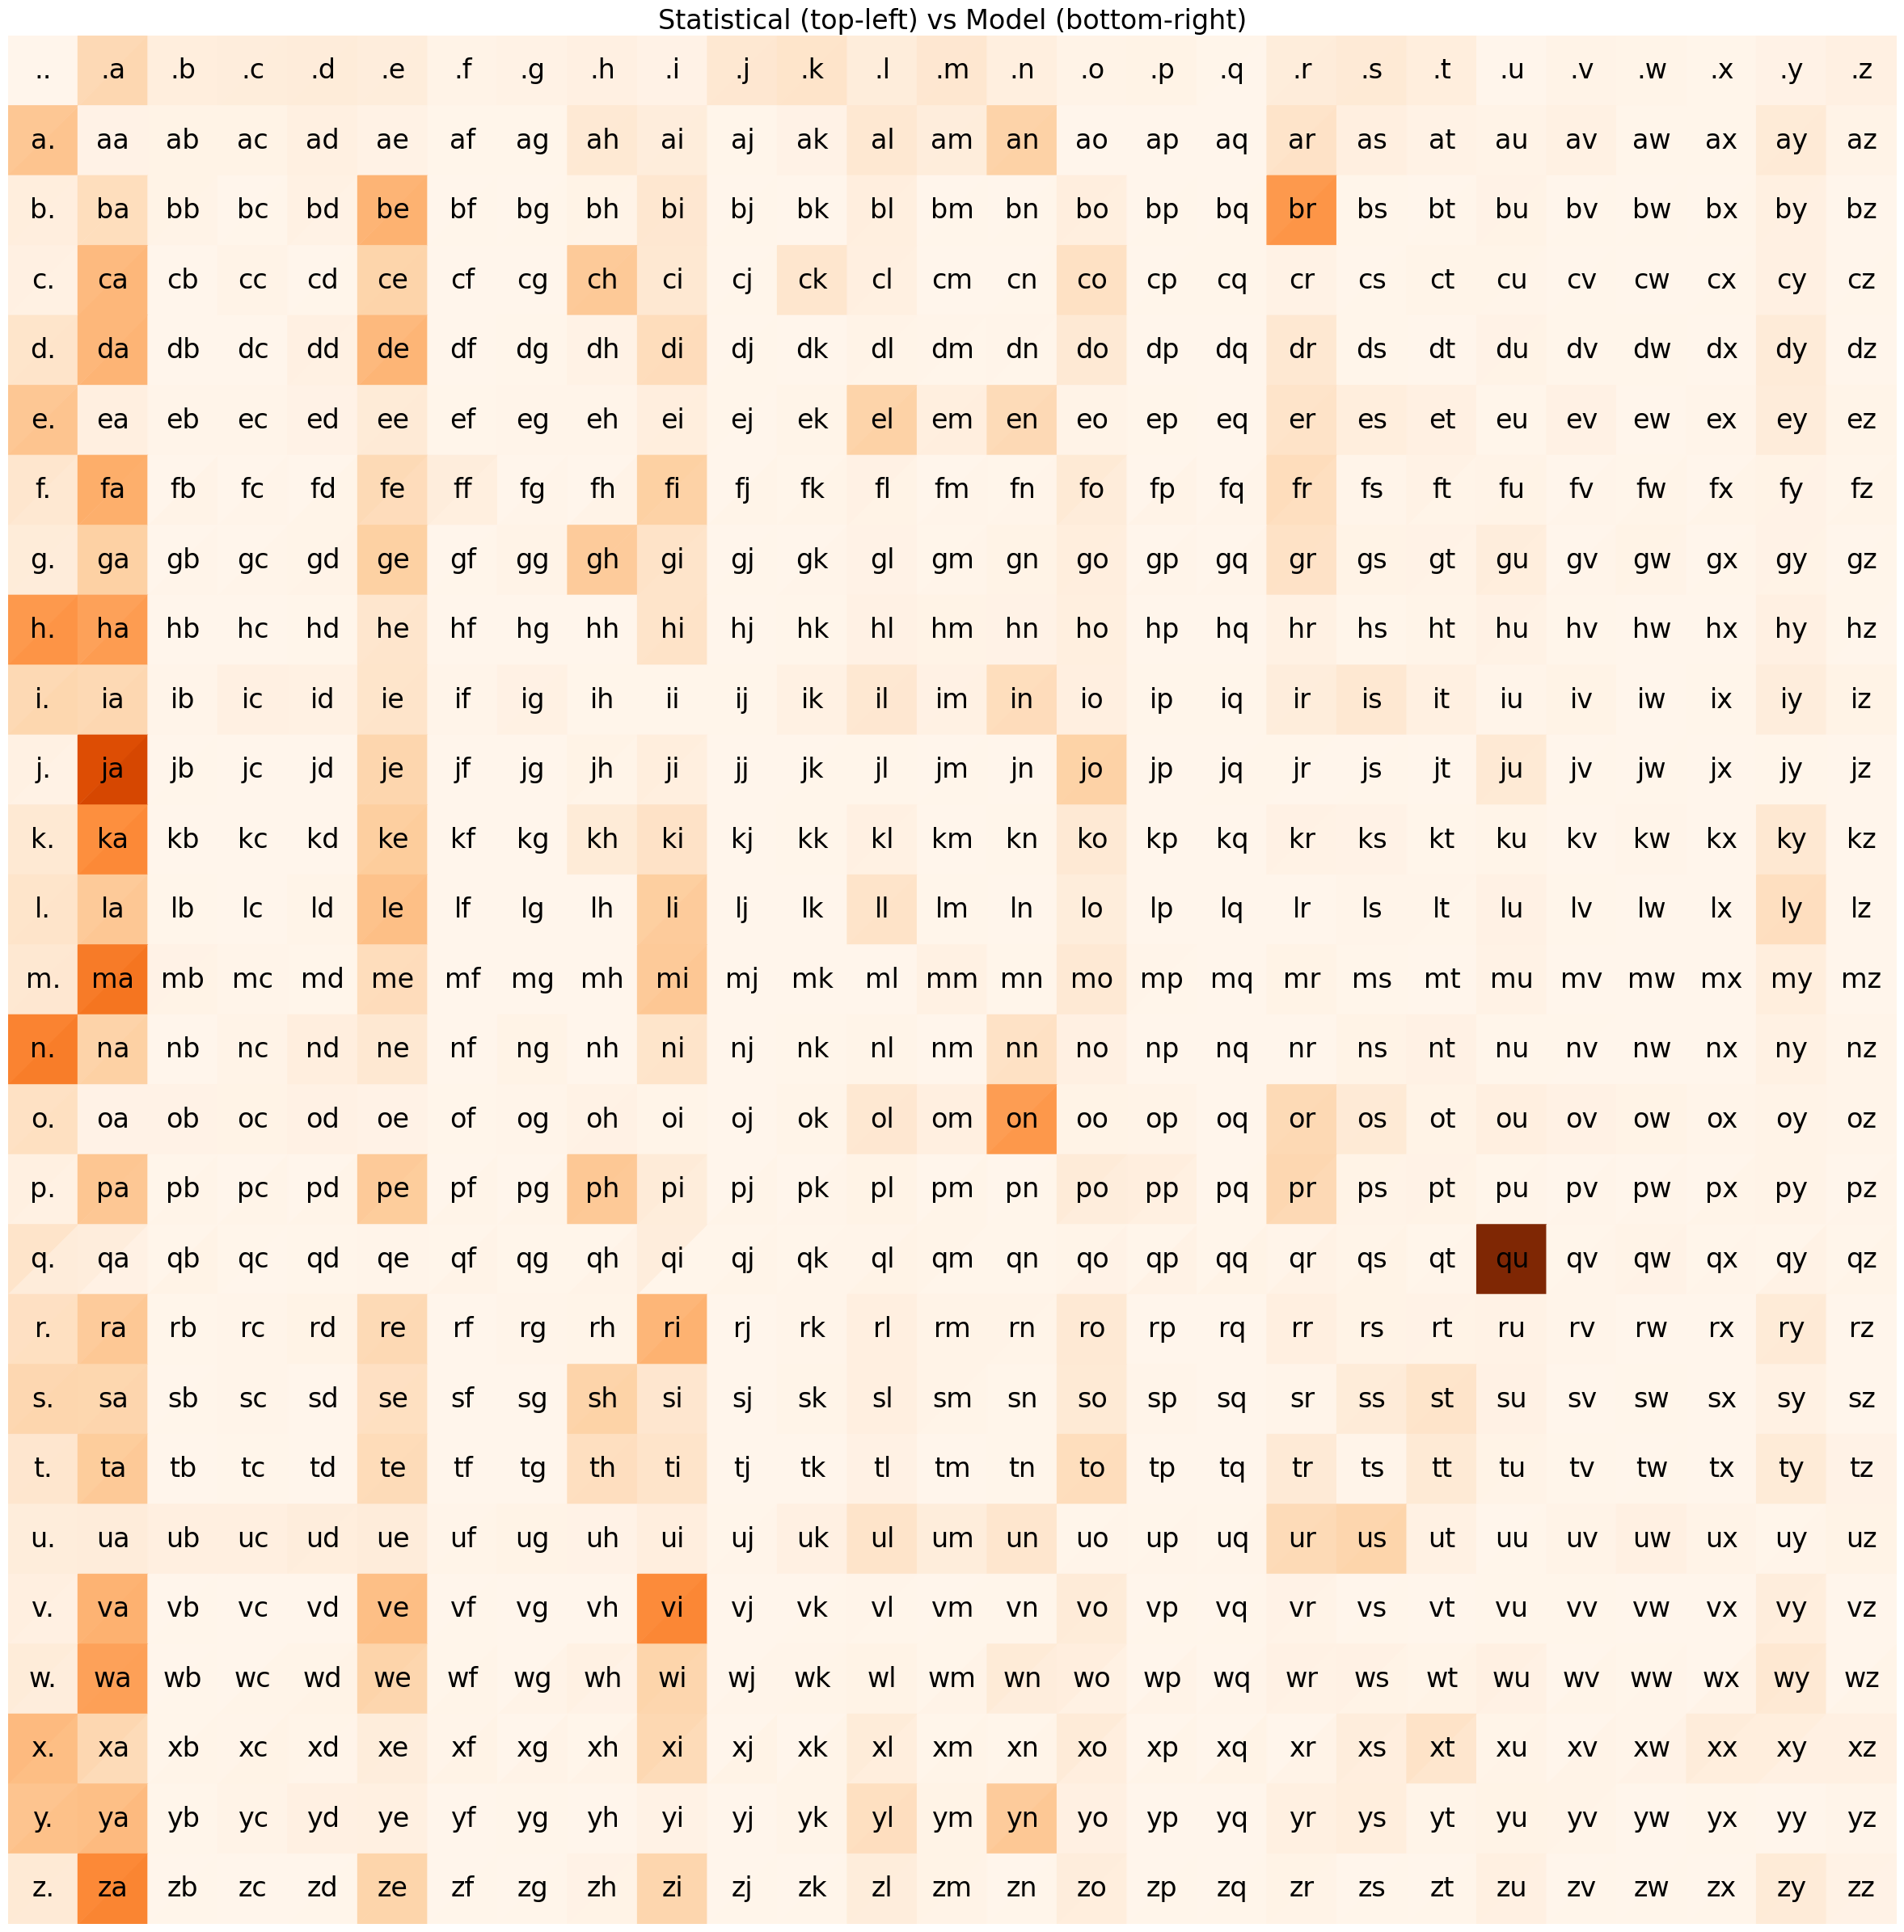

In [110]:
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(24, 24))

norm_p = mcolors.Normalize(vmin=p.data.min(), vmax=p.data.max())
norm_P = mcolors.Normalize(vmin=P.min(), vmax=P.max())

for i in range(27):
    for j in range(27):
        x0, x1 = j - 0.5, j + 0.5
        y0, y1 = i - 0.5, i + 0.5

        # top-left triangle — statistical
        ax.add_patch(patches.Polygon(
            [(x0, y0), (x1, y0), (x0, y1)],
            color=cm.Oranges(norm_P(P[i, j].item()))
        ))
        # bottom-right triangle — model
        ax.add_patch(patches.Polygon(
            [(x1, y0), (x1, y1), (x0, y1)],
            color=cm.Oranges(norm_p(p.data[i, j].item()))
        ))

        chstr = itos[i] + itos[j]
        ax.text(j, i, chstr, ha='center', va='center', color='black', fontsize=24)

ax.set_xlim(-0.5, 26.5)
ax.set_ylim(26.5, -0.5)  # invert to match imshow orientation
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Statistical (top-left) vs Model (bottom-right)', fontsize=24)
plt.tight_layout()